# 마음잇다 - 텍스트 감정분류 모델 파인튜닝 (Colab)

3개 후보 모델(**A.X-Encoder-base** / **KcELECTRA-base-v2023** / **KLUE-RoBERTa-base**)을 동일 조건으로 파인튜닝하고, **validation macro F1** 기준으로 최종 후보를 선택한다 (test는 최종 확인용, 선택 기준에 관여하지 않음). `train_emotion_classifier.py`와 동일한 로직을 셀 단위로 나눈 노트북.

## 실행 전 필독 - 알려진 구조적 한계

**1. 중립<->불안 source confound** — `source_dataset==1`은 불안 0건, `{3,4}`는 중립 0건으로 완전히 결정론적. "중립 vs 불안" 구분이 감정 내용이 아니라 문체 차이로 풀렸을 위험. `detailed_evaluation()`의 중립<->불안 혼동 진단으로 확인할 것.

**2. context가 배포 시 사라지는 신호로 라벨을 예측함** — source=3·4(전체 72%)는 원본이 "한 상황=한 라벨" 구조라 context(사람문장1)와 text(사람문장2)가 사실상 같은 감정을 두 번 말함(간이 NB 기준 context 0.681 > text 0.589, source=1에서는 반대로 text 0.714 > context 0.633이 정상). 서빙 시점 context는 LLM 발화라 이 신호가 실제로는 없음 → train-serving mismatch. 데이터 삭제로 못 고치는 설계 문제라 두 가지로 대응:
  - `context_ablation_check()`: 실제 트랜스포머로 context-only/text-only/both를 빠르게 비교 (RUN_ABLATION=True)
  - `CONTEXT_DROPOUT_PROB`: source in {3,4}의 train 행에 한해 확률적으로 context를 같은 source 내 다른 행 context로 바꿔치기(val/test는 항상 원본)

**3. 노년층 x 중립 교집합 0건** — 중립은 source=1에만 있는데 source=1은 age_group이 전부 '알수없음'이라, `age_group=='노년'` 부분집합엔 중립 정답이 구조적으로 없음(4-class로만 평가 가능). `detailed_evaluation()`이 이를 조용히 넘기지 않고 명시적으로 경고한다.

## 데이터 출처 - 반드시 확인

`데이터셋/00 전처리 텍스트 데이터/06_전처리_완료_텍스트_데이터셋/`(2026-07-30 17:25 최종본, train 46,648 / val 5,816 / test 5,877 — split간 근사중복 137행 재배정까지 반영)만 사용할 것. 같은 프로젝트의 `모델학습/data_v2/`는 같은 날 15:48에 만든 그 패치 **이전** 스냅샷(train 46,647 / val 5,859 / test 5,837)이라 이미 고쳐진 split-누수가 남아있음 — 학습에 쓰지 말 것.

원본 CSV가 UTF-8 BOM으로 시작하므로 `encoding="utf-8-sig"`로 읽어야 함(아래 `load_split`에 반영됨).

## 0. 환경 설정

In [1]:
# torch는 Colab에 이미 CUDA 빌드로 설치되어 있으니 건드리지 않는다(재설치 시 CUDA 버전 꼬일 위험).
!pip install -q "transformers>=4.51.0" datasets scikit-learn accelerate sentencepiece

In [2]:
# Google Drive 마운트
# - 폴더 구조를 프로젝트와 똑같이 맞출 필요 없음. Drive 아무 데나(예: 내 드라이브 최상위)
#   'mindida_data'라는 폴더 하나만 새로 만들고, 그 안에 train.csv / val.csv / test.csv
#   3개 파일만 바로 넣으면 됨(하위 폴더 없이 flat하게).
# - OUTPUT_ROOT도 Drive 경로로 둬야 런타임 종료 후에도 학습된 모델/결과가 남는다.
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/mindida_data"
OUTPUT_ROOT = "/content/drive/MyDrive/mindida_output"

Mounted at /content/drive


In [3]:
# (대안) Drive 마운트 대신 파일을 직접 업로드하고 싶다면 위 마운트 셀 대신 아래를 사용.
# 이 경우 OUTPUT_ROOT는 세션 종료 시 사라지니, 학습 후 결과를 별도로 다운로드해둘 것.
#
# from google.colab import files
# uploaded = files.upload()  # train.csv, val.csv, test.csv 선택
# import os
# os.makedirs("./data", exist_ok=True)
# for fname in uploaded:
#     os.rename(fname, f"./data/{fname}")
# DATA_DIR = "./data"
# OUTPUT_ROOT = "./runs"

In [4]:
# DATA_DIR 검증 - 경로를 정확히 안 맞춰도 되도록, 없으면 Drive 전체에서 자동으로 찾는다.
# (train.csv/val.csv/test.csv가 같이 있는 폴더를 재귀 탐색해서 후보를 보여주고,
#  단 하나만 발견되면 DATA_DIR을 그걸로 자동 교체한다.)
import os
import glob


def _has_all_splits(folder):
    return all(os.path.exists(os.path.join(folder, f"{n}.csv")) for n in ("train", "val", "test"))


if not _has_all_splits(DATA_DIR):
    print(f"[안내] DATA_DIR={DATA_DIR} 에 train/val/test.csv가 없음 -> Drive 전체에서 자동 탐색합니다.")
    candidates = sorted({
        os.path.dirname(p)
        for p in glob.glob("/content/drive/MyDrive/**/train.csv", recursive=True)
        if _has_all_splits(os.path.dirname(p))
    })
    if len(candidates) == 1:
        DATA_DIR = candidates[0]
        print(f"[자동 설정] train/val/test.csv가 모두 있는 폴더를 1개 찾음 -> DATA_DIR = {DATA_DIR}")
    elif len(candidates) > 1:
        print("[확인 필요] train/val/test.csv가 모두 있는 폴더가 여러 개 발견됨. 아래 중 맞는 걸 골라 DATA_DIR에 직접 대입할 것:")
        for c in candidates:
            print(" -", c)
        raise FileNotFoundError("DATA_DIR을 위 후보 중 하나로 직접 지정한 뒤 이 셀부터 다시 실행하세요.")
    else:
        raise FileNotFoundError(
            "Drive 어디에서도 train.csv/val.csv/test.csv가 같이 있는 폴더를 찾지 못했습니다. "
            "Drive에 세 파일을 업로드했는지, 마운트가 됐는지 다시 확인할 것."
        )
else:
    print(f"[확인 완료] DATA_DIR = {DATA_DIR}")

os.makedirs(OUTPUT_ROOT, exist_ok=True)
print(f"OUTPUT_ROOT = {OUTPUT_ROOT}")

[확인 완료] DATA_DIR = /content/drive/MyDrive/mindida_data
OUTPUT_ROOT = /content/drive/MyDrive/mindida_output


## 1. 설정값 및 공통 import

In [5]:
import os
import json
import random
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset
from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)

SEED = 42
MAX_LENGTH = 192  # context+text 99%ile 커버 (분석 근거: 변경사항 참고)
NUM_EPOCHS = 4
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
LEARNING_RATE = 2e-5

# source=3,4는 context가 text와 같은 감정을 반복하는 구조라 서빙 시점엔 없는 신호에
# 모델이 과의존할 위험이 있음. train에서만, 이 확률로 같은 source의 다른 행
# context로 바꿔치기해서 과의존을 줄인다. 0.0으로 두면 비활성.
CONTEXT_DROPOUT_PROB = 0.5
CONTEXT_DROPOUT_SOURCES = {3, 4}

# True로 켜면 본 학습 전에 KLUE-RoBERTa-base로 context-only/text-only/both 3종을
# 짧게(1 epoch) 학습해서, 간이 NB로 발견된 "source=3·4에서 context가 더 잘 맞힘" 현상이
# 실제 트랜스포머에도 재현되는지 먼저 확인한다. 확인 후 꺼도 됨.
RUN_ABLATION = False
ABLATION_MODEL = "klue/roberta-base"
ABLATION_EPOCHS = 1

LABELS = ["기쁨", "분노", "슬픔", "불안", "중립"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

MODEL_CANDIDATES = {
    "AX-Encoder-base": "skt/A.X-Encoder-base",
    "KcELECTRA-v2023": "beomi/KcELECTRA-base",
    "KLUE-RoBERTa-base": "klue/roberta-base",
}

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. 데이터 로드 + Dataset (context dropout 포함)

In [6]:
def load_split(name: str) -> pd.DataFrame:
    path = os.path.join(DATA_DIR, f"{name}.csv")
    df = pd.read_csv(path, encoding="utf-8-sig")  # 원본 CSV가 UTF-8 BOM으로 시작함
    missing = set(["context", "text", "label", "source_dataset", "age_group"]) - set(df.columns)
    if missing:
        raise ValueError(f"{path}에 필요한 컬럼이 없습니다: {missing}")
    df["label_id"] = df["label"].map(LABEL2ID)
    if df["label_id"].isna().any():
        bad = df[df["label_id"].isna()]["label"].unique()
        raise ValueError(f"알 수 없는 라벨 값 발견: {bad}")
    return df


class EmotionDataset(Dataset):
    """context+text를 문장쌍으로 인코딩하는 Dataset.

    context_dropout_prob > 0이면, source_dataset이 dropout_sources에 속하는 행에 한해
    그 확률로 context를 "같은 source의 다른 무작위 행" context로 바꿔치기한다.
    source=3·4는 context(사람문장1)와 text(사람문장2)가 같은 감정을 두 번 말하는 구조라,
    원본 context를 그대로 쓰면 실제 서빙 때는 없는 "감정 반복" 신호에 모델이 과의존하게
    됨. 학습(train)에서만 켜고, val/test는 항상 원본 그대로 평가해야 "실제로 얼마나
    좋아졌는지"를 왜곡 없이 볼 수 있다.

    use_token_type_ids=False면 토크나이저가 token_type_ids를 반환해도 버린다.
    klue/roberta-base처럼 모델의 type_vocab_size가 1인데 토크나이저는 문장쌍용
    token_type_ids(0/1)를 내놓는 경우, 그 값을 그대로 넘기면 임베딩 테이블 크기를
    벗어나 CUDA device-side assert가 남 — 그 문제를 피하기 위한 옵션.
    """

    def __init__(
        self,
        df: pd.DataFrame,
        tokenizer,
        max_length: int,
        context_dropout_prob: float = 0.0,
        dropout_sources=frozenset(),
        seed: int = SEED,
        use_token_type_ids: bool = True,  # 추가
    ):
        self.contexts = df["context"].astype(str).tolist()
        self.texts = df["text"].astype(str).tolist()
        self.labels = df["label_id"].astype(int).tolist()
        self.sources = df["source_dataset"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.context_dropout_prob = context_dropout_prob
        self.dropout_sources = set(dropout_sources)
        self.use_token_type_ids = use_token_type_ids  # 추가
        self._rng = random.Random(seed)

        # source별 context 후보 풀(바꿔치기용) 미리 만들어둠
        self._pool_by_source = {}
        if context_dropout_prob > 0:
            for src in self.dropout_sources:
                idxs = [i for i, s in enumerate(self.sources) if s == src]
                if idxs:
                    self._pool_by_source[src] = idxs

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        context = self.contexts[idx]
        src = self.sources[idx]
        if (
            self.context_dropout_prob > 0
            and src in self.dropout_sources
            and self._rng.random() < self.context_dropout_prob
        ):
            pool = self._pool_by_source.get(src)
            if pool:
                swap_idx = self._rng.choice(pool)
                context = self.contexts[swap_idx]

        enc = self.tokenizer(
            context,
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
        )
        if not self.use_token_type_ids:
            enc.pop("token_type_ids", None)  # 추가 — 있으면 지우고, 없으면 그냥 통과
        enc = {k: torch.tensor(v) for k, v in enc.items()}
        enc["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return enc

## 3. context ablation 체크 (선택 실행)

source=3·4에서 context가 text보다 라벨을 더 잘 맞히는 문제가 실제 트랜스포머에도 재현되는지 빠르게 확인한다. `RUN_ABLATION=True`로 켠 뒤 아래 셀들을 실행하면 본 학습 대신 이 체크만 돌고 종료된다.

In [7]:
def context_ablation_check(train_df, val_df):
    """context-only / text-only / both 3가지 입력으로 짧게(ABLATION_EPOCHS) 학습해서
    source=1 vs source=3·4에서 context/text 중 뭐가 더 라벨을 잘 맞히는지 확인한다.

    간이 Naive Bayes 진단(문자 n-gram 기준)을 실제 트랜스포머 아키텍처로 재확인하는
    목적. NB는 단어/문자 빈도만 보고 문맥을 이해 못 하니, 어텐션 기반 모델은 다른
    결과를 보일 수도 있어 결론 내리기 전에 확인한다.
    """
    print("\n" + "#" * 70)
    print("# context ablation 체크 시작 (독립검증에서 발견된 train-serving mismatch 재확인)")
    print("#" * 70)

    tokenizer = AutoTokenizer.from_pretrained(ABLATION_MODEL)

    variants = {
        "context_only": lambda df: df.assign(text="."),
        "text_only": lambda df: df.assign(context="."),
        "both": lambda df: df,
    }

    ablation_results = {}
    for variant_name, transform in variants.items():
        print(f"\n--- variant: {variant_name} ---")
        v_train = transform(train_df)
        v_val = transform(val_df)

        model = AutoModelForSequenceClassification.from_pretrained(
            ABLATION_MODEL, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID,
            torch_dtype=torch.float32,  # 체크포인트가 bf16로 저장돼 있어도 fp32로 강제(fp16 AMP와 dtype 충돌 방지)
        )
        train_ds = EmotionDataset(v_train, tokenizer, MAX_LENGTH)
        val_ds = EmotionDataset(v_val, tokenizer, MAX_LENGTH)

        args = TrainingArguments(
            output_dir=os.path.join(OUTPUT_ROOT, "ablation", variant_name),
            num_train_epochs=ABLATION_EPOCHS,
            per_device_train_batch_size=TRAIN_BATCH_SIZE,
            per_device_eval_batch_size=EVAL_BATCH_SIZE,
            learning_rate=LEARNING_RATE,
            eval_strategy="no",
            save_strategy="no",
            fp16=torch.cuda.is_available(),
            logging_steps=100,
            report_to=[],
            seed=SEED,
        )
        trainer = Trainer(model=model, args=args, train_dataset=train_ds, data_collator=DataCollatorWithPadding(tokenizer=tokenizer))
        trainer.train()

        pred_output = trainer.predict(val_ds)
        preds = np.argmax(pred_output.predictions, axis=-1)
        labels = pred_output.label_ids
        v_val = v_val.reset_index(drop=True)

        for src_group, mask in [
            ("source=1", v_val["source_dataset"] == 1),
            ("source=3,4", v_val["source_dataset"].isin([3, 4])),
        ]:
            if mask.sum() == 0:
                continue
            acc = (preds[mask.values] == labels[mask.values]).mean()
            print(f"    {src_group} (n={mask.sum()}): accuracy={acc:.4f}")
            ablation_results[f"{variant_name}__{src_group}"] = float(acc)

    print("\n--- context ablation 요약 ---")
    for k, v in ablation_results.items():
        print(f"  {k}: {v:.4f}")
    print(
        "판단 기준: source=3,4에서 context_only가 text_only보다 뚜렷이 높으면(간이 NB로\n"
        "확인한 것과 같은 패턴) CONTEXT_DROPOUT_PROB을 켠 채로 본 학습을 진행할 것을 권장.\n"
        "source=1에서는 정상적으로 text_only가 context_only보다 높아야 함(원래 의도한 동작)."
    )
    return ablation_results

## 4. 클래스 불균형 대응(weighted loss) + 평가 지표

In [8]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss_fct = nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits.view(-1, logits.size(-1)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

## 5. 세부 평가 (전체 / source_dataset별 / 노년층 subset)

In [9]:
def detailed_evaluation(trainer, dataset: EmotionDataset, df: pd.DataFrame, tag: str) -> dict:
    pred_output = trainer.predict(dataset)
    preds = np.argmax(pred_output.predictions, axis=-1)
    labels = pred_output.label_ids

    result = {
        "tag": tag,
        "n": len(labels),
        "f1_macro_overall": f1_score(labels, preds, average="macro"),
    }

    print(f"\n[{tag}] 전체 macro F1: {result['f1_macro_overall']:.4f} (n={result['n']})")
    print(classification_report(labels, preds, target_names=LABELS, digits=3))

    # source_dataset별
    df = df.copy()
    df["_pred"] = preds
    df["_label"] = labels
    for src, sub in df.groupby("source_dataset"):
        f1 = f1_score(sub["_label"], sub["_pred"], average="macro")
        print(f"  - source_dataset={src} (n={len(sub)}): macro F1={f1:.4f}")
        result[f"f1_macro_source_{src}"] = f1

    # 노년층 subset (실제 배포 대상과의 정합성 확인용 — 핵심 지표)
    # 주의: 중립은 source=1에만 있고 source=1은 age_group이 전부 '알수없음'이라,
    # 노년 subset엔 중립 정답이 구조적으로 0건임. labels=range(5)를 명시 안 하면
    # sklearn이 y_true에 없는 클래스를 조용히 평균에서 빼버려서 "4-class macro F1"이
    # "5-class macro F1"인 것처럼 보일 수 있다 — 그래서 support를 직접 세서 경고로 남긴다.
    elderly = df[df["age_group"] == "노년"]
    if len(elderly) > 0:
        present_labels = sorted(elderly["_label"].unique().tolist())
        missing_labels = [ID2LABEL[i] for i in range(len(LABELS)) if i not in present_labels]
        f1_elderly = f1_score(elderly["_label"], elderly["_pred"], labels=present_labels, average="macro")
        note = f" (주의: {missing_labels} 클래스는 노년 subset에 정답 자체가 없어 {len(present_labels)}-class로만 계산됨 — 측정 불가 상태)" if missing_labels else ""
        print(f"  - age_group=노년 (n={len(elderly)}): macro F1={f1_elderly:.4f}  <- 배포 대상 실성능{note}")
        result["f1_macro_elderly"] = f1_elderly
        result["f1_macro_elderly_classes_missing"] = missing_labels
    else:
        result["f1_macro_elderly"] = None
        result["f1_macro_elderly_classes_missing"] = None

    # 중립<->불안 혼동 별도 체크
    # source_dataset==1 이면 불안이 0건, source_dataset in {3,4}면 중립이 0건인
    # 결정론적 confound가 있음. source별 성능이 각각 좋아도 이 구간 자체는 "감정 내용"이
    # 아니라 "출처 문체"로 풀렸을 위험이 있어 별도로 남긴다.
    neutral_id, anxiety_id = LABEL2ID["중립"], LABEL2ID["불안"]
    na_mask = df["_label"].isin([neutral_id, anxiety_id])
    if na_mask.sum() > 0:
        na_sub = df[na_mask]
        na_acc = (na_sub["_pred"] == na_sub["_label"]).mean()
        neutral_as_anxiety = ((na_sub["_label"] == neutral_id) & (na_sub["_pred"] == anxiety_id)).sum()
        anxiety_as_neutral = ((na_sub["_label"] == anxiety_id) & (na_sub["_pred"] == neutral_id)).sum()
        print(
            f"  - [주의] 중립<->불안 혼동 체크 (source-라벨 confound 있음, n={len(na_sub)}): "
            f"정확도={na_acc:.4f}, 중립->불안 오분류={neutral_as_anxiety}건, 불안->중립 오분류={anxiety_as_neutral}건"
        )
        result["neutral_anxiety_accuracy"] = na_acc
        result["neutral_as_anxiety_errors"] = int(neutral_as_anxiety)
        result["anxiety_as_neutral_errors"] = int(anxiety_as_neutral)

    return result

## 6. 모델별 학습 루프

In [10]:
def train_one_model(model_key: str, model_name: str, train_df, val_df, test_df, class_weights):
    print("\n" + "=" * 70)
    print(f"학습 시작: {model_key} ({model_name})")
    print("=" * 70)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(LABELS),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        torch_dtype=torch.float32,  # 체크포인트가 bf16로 저장돼 있어도 fp32로 강제(fp16 AMP와 dtype 충돌 방지)
    )

    # 모델이 실제로 처리 가능한 token_type 개수를 보고 결정 — 토크나이저가 뭘
    # 내놓든 상관없이, 임베딩 테이블 크기(type_vocab_size)가 1 이하면 그 필드를 버린다.
    use_tti = getattr(model.config, "type_vocab_size", 2) > 1  # 추가
    print(f"  type_vocab_size={getattr(model.config, 'type_vocab_size', None)} -> use_token_type_ids={use_tti}")  # 추가

    # train에만 context dropout 적용, val/test는 항상 원본 그대로 평가
    train_ds = EmotionDataset(
        train_df, tokenizer, MAX_LENGTH,
        context_dropout_prob=CONTEXT_DROPOUT_PROB,
        dropout_sources=CONTEXT_DROPOUT_SOURCES,
        use_token_type_ids=use_tti,  # 추가
    )
    val_ds = EmotionDataset(val_df, tokenizer, MAX_LENGTH, use_token_type_ids=use_tti)  # 추가
    test_ds = EmotionDataset(test_df, tokenizer, MAX_LENGTH, use_token_type_ids=use_tti)  # 추가

    output_dir = os.path.join(OUTPUT_ROOT, model_key)
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        report_to=[],
        seed=SEED,
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
        class_weights=class_weights,
    )

    trainer.train()

    # epoch별 train loss / eval loss / eval F1 추이 - 그래프용으로 그대로 보관
    log_history = trainer.state.log_history

    val_result = detailed_evaluation(trainer, val_ds, val_df, tag=f"{model_key}/val")
    test_result = detailed_evaluation(trainer, test_ds, test_df, tag=f"{model_key}/test")

    best_model_path = os.path.join(output_dir, "best_model")
    trainer.save_model(best_model_path)
    tokenizer.save_pretrained(best_model_path)

    return {
        "model_key": model_key,
        "model_name": model_name,
        "best_model_path": best_model_path,
        "log_history": log_history,
        "val": val_result,
        "test": test_result,
    }

## 7. 실행 - 모델별 셀로 분리

한 셀에서 3모델을 몰아 돌리지 않고, 모델 하나씩 별도 셀로 나눴다. 이렇게 하면 특정 모델에서
에러가 나도 그 셀만 다시 고쳐서 재실행하면 되고, 이미 끝난 모델을 다시 돌릴 필요가 없다.

순서: (1) 데이터 로드+가중치 계산(1회) → (2)~(4) 모델별 학습(순서 무관, 하나씩 실행) → (5) 세
모델 결과를 모아 최종 비교. (2)~(4) 중 아직 안 돌린/실패한 모델이 있어도 (5)는 실행 가능 —
있는 결과만으로 비교표를 만들고 없는 건 안내만 출력한다.

In [ ]:
# (1) 데이터 로드 + 클래스 가중치 계산 - 아래 모델별 셀들을 실행하기 전에 딱 한 번 실행
train_df = load_split("train")
val_df = load_split("val")
test_df = load_split("test")

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")
print(f"CONTEXT_DROPOUT_PROB={CONTEXT_DROPOUT_PROB} (source {CONTEXT_DROPOUT_SOURCES}에만 적용, train만)")

# 참고: RUN_ABLATION 체크를 먼저 해보고 싶으면 위 셀들 실행 후 여기서 바로
#   context_ablation_check(train_df, val_df)
# 를 별도 셀에서 호출하면 된다(본 학습과 독립적으로 실행 가능).

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(LABELS)),
    y=train_df["label_id"].values,
)
class_weights = torch.tensor(class_weights_arr, dtype=torch.float)
print("class_weights:", dict(zip(LABELS, class_weights_arr.round(3))))

train=46648  val=5816  test=5877
CONTEXT_DROPOUT_PROB=0.5 (source {3, 4}에만 적용, train만)
class_weights: {'기쁨': np.float64(1.368), '분노': np.float64(0.847), '슬픔': np.float64(0.881), '불안': np.float64(1.078), '중립': np.float64(0.976)}


In [ ]:
# (2) 모델 1/3: AX-Encoder-base
# 에러 나면 이 셀만 다시 고쳐서 재실행하면 됨 (다른 모델 셀에는 영향 없음)
result_ax = train_one_model(
    "AX-Encoder-base", MODEL_CANDIDATES["AX-Encoder-base"],
    train_df, val_df, test_df, class_weights,
)


학습 시작: AX-Encoder-base (skt/A.X-Encoder-base)


config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/6.95k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/969 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[AX-Encoder-base/val] 전체 macro F1: 0.7505 (n=5816)
              precision    recall  f1-score   support

          기쁨      0.900     0.829     0.863       860
          분노      0.738     0.634     0.682      1361
          슬픔      0.752     0.573     0.650      1297
          불안      0.611     0.845     0.709      1080
          중립      0.800     0.901     0.848      1218

    accuracy                          0.744      5816
   macro avg      0.760     0.757     0.751      5816
weighted avg      0.755     0.744     0.742      5816

  - source_dataset=1 (n=1742): macro F1=0.4252
  - source_dataset=3 (n=3918): macro F1=0.6007
  - source_dataset=4 (n=156): macro F1=0.5825
  - age_group=노년 (n=1237): macro F1=0.7144  <- 배포 대상 실성능 (주의: ['중립'] 클래스는 노년 subset에 정답 자체가 없어 4-class로만 계산됨 — 측정 불가 상태)
  - [주의] 중립<->불안 혼동 체크 (source-라벨 confound 있음, n=2298): 정확도=0.8751, 중립->불안 오분류=7건, 불안->중립 오분류=2건



[AX-Encoder-base/test] 전체 macro F1: 0.7535 (n=5877)
              precision    recall  f1-score   support

          기쁨      0.903     0.838     0.869       865
          분노      0.753     0.646     0.695      1371
          슬픔      0.761     0.573     0.654      1341
          불안      0.615     0.832     0.707      1083
          중립      0.781     0.913     0.842      1217

    accuracy                          0.747      5877
   macro avg      0.763     0.760     0.753      5877
weighted avg      0.757     0.747     0.744      5877

  - source_dataset=1 (n=1822): macro F1=0.4547
  - source_dataset=3 (n=3906): macro F1=0.6061
  - source_dataset=4 (n=149): macro F1=0.7795
  - age_group=노년 (n=1205): macro F1=0.7461  <- 배포 대상 실성능 (주의: ['중립'] 클래스는 노년 subset에 정답 자체가 없어 4-class로만 계산됨 — 측정 불가 상태)
  - [주의] 중립<->불안 혼동 체크 (source-라벨 confound 있음, n=2300): 정확도=0.8748, 중립->불안 오분류=1건, 불안->중립 오분류=0건


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# (3) 모델 2/3: KcELECTRA-v2023
result_kc = train_one_model(
    "KcELECTRA-v2023", MODEL_CANDIDATES["KcELECTRA-v2023"],
    train_df, val_df, test_df, class_weights,
)


학습 시작: KcELECTRA-v2023 (beomi/KcELECTRA-base)


config.json:   0%|          | 0.00/514 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[KcELECTRA-v2023/val] 전체 macro F1: 0.7518 (n=5816)
              precision    recall  f1-score   support

          기쁨      0.862     0.850     0.856       860
          분노      0.701     0.672     0.686      1361
          슬픔      0.672     0.675     0.673      1297
          불안      0.687     0.719     0.703      1080
          중립      0.837     0.846     0.841      1218

    accuracy                          0.744      5816
   macro avg      0.752     0.752     0.752      5816
weighted avg      0.744     0.744     0.744      5816

  - source_dataset=1 (n=1742): macro F1=0.4490
  - source_dataset=3 (n=3918): macro F1=0.6019
  - source_dataset=4 (n=156): macro F1=0.7406
  - age_group=노년 (n=1237): macro F1=0.7117  <- 배포 대상 실성능 (주의: ['중립'] 클래스는 노년 subset에 정답 자체가 없어 4-class로만 계산됨 — 측정 불가 상태)
  - [주의] 중립<->불안 혼동 체크 (source-라벨 confound 있음, n=2298): 정확도=0.7859, 중립->불안 오분류=0건, 불안->중립 오분류=1건



[KcELECTRA-v2023/test] 전체 macro F1: 0.7520 (n=5877)
              precision    recall  f1-score   support

          기쁨      0.857     0.836     0.846       865
          분노      0.715     0.699     0.707      1371
          슬픔      0.682     0.658     0.669      1341
          불안      0.697     0.717     0.706      1083
          중립      0.809     0.855     0.831      1217

    accuracy                          0.745      5877
   macro avg      0.752     0.753     0.752      5877
weighted avg      0.744     0.745     0.744      5877

  - source_dataset=1 (n=1822): macro F1=0.4616
  - source_dataset=3 (n=3906): macro F1=0.6043
  - source_dataset=4 (n=149): macro F1=0.8483
  - age_group=노년 (n=1205): macro F1=0.7527  <- 배포 대상 실성능 (주의: ['중립'] 클래스는 노년 subset에 정답 자체가 없어 4-class로만 계산됨 — 측정 불가 상태)
  - [주의] 중립<->불안 혼동 체크 (source-라벨 confound 있음, n=2300): 정확도=0.7896, 중립->불안 오분류=1건, 불안->중립 오분류=0건


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# (4) 모델 3/3: KLUE-RoBERTa-base
result_klue = train_one_model(
    "KLUE-RoBERTa-base", MODEL_CANDIDATES["KLUE-RoBERTa-base"],
    train_df, val_df, test_df, class_weights,
)


학습 시작: KLUE-RoBERTa-base (klue/roberta-base)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: klue/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  type_vocab_size=1 -> use_token_type_ids=False


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [12]:
# (5) 최종 비교 - (2)~(4) 중 실행된(변수가 존재하는) 모델만 모아서 비교표를 만든다.
# 아직 안 돌렸거나 실패해서 변수가 없는 모델은 안내만 출력하고 건너뛴다.
# 모델 선택 기준: val_f1_macro (validation set). test는 최종 확인용으로만 참고하고
# 순위 결정에는 관여하지 않는다(위쪽 셀에서 이미 val로 checkpoint를 고른 상태).

_model_vars = [
    ("AX-Encoder-base", "result_ax"),
    ("KcELECTRA-v2023", "result_kc"),
    ("KLUE-RoBERTa-base", "result_klue"),
]

summary = []
for _key, _var in _model_vars:
    if _var in globals() and globals()[_var] is not None:
        summary.append(globals()[_var])
    else:
        print(f"[안내] {_key} 결과 변수({_var})가 없음 — 위 학습 셀을 먼저 실행할 것. 일단 이 모델은 비교표에서 제외.")

if not summary:
    print("\n아직 완료된 모델이 하나도 없습니다. (2)~(4) 중 하나 이상 실행 후 이 셀을 다시 실행하세요.")
else:
    print("\n" + "=" * 70)
    print("최종 비교 (val macro F1 기준으로 모델 선택, test는 최종 확인용)")
    print("=" * 70)
    rows = []
    for r in summary:
        rows.append({
            "model": r["model_key"],
            "val_f1_macro": r["val"]["f1_macro_overall"],
            "val_elderly_f1_macro": r["val"]["f1_macro_elderly"],
            "test_f1_macro": r["test"]["f1_macro_overall"],
            "test_elderly_f1_macro": r["test"]["f1_macro_elderly"],
        })
    result_df = pd.DataFrame(rows).sort_values("val_f1_macro", ascending=False)
    print(result_df.to_string(index=False))
    os.makedirs(OUTPUT_ROOT, exist_ok=True)
    result_df.to_csv(os.path.join(OUTPUT_ROOT, "model_comparison.csv"), index=False)

    with open(os.path.join(OUTPUT_ROOT, "full_results.json"), "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2, default=str)

    print(f"\n비교표 저장: {os.path.join(OUTPUT_ROOT, 'model_comparison.csv')}")
    print("val_f1_macro가 가장 높은 모델을 최종 후보로 선택. test_f1_macro/test_elderly_f1_macro는")
    print("그 선택이 test에서도 무너지지 않는지 확인하는 용도로만 참고할 것 (test 기준으로 재선택 금지).")

[안내] AX-Encoder-base 결과 변수(result_ax)가 없음 — 위 학습 셀을 먼저 실행할 것. 일단 이 모델은 비교표에서 제외.
[안내] KcELECTRA-v2023 결과 변수(result_kc)가 없음 — 위 학습 셀을 먼저 실행할 것. 일단 이 모델은 비교표에서 제외.
[안내] KLUE-RoBERTa-base 결과 변수(result_klue)가 없음 — 위 학습 셀을 먼저 실행할 것. 일단 이 모델은 비교표에서 제외.

아직 완료된 모델이 하나도 없습니다. (2)~(4) 중 하나 이상 실행 후 이 셀을 다시 실행하세요.


In [ ]:
import json, os
for _key, _var in [("AX-Encoder-base", "result_ax"), ("KcELECTRA-v2023", "result_kc")]:
    if _var in globals():
        with open(os.path.join(OUTPUT_ROOT, f"{_key}_result.json"), "w", encoding="utf-8") as f:
            json.dump(globals()[_var], f, ensure_ascii=False, indent=2, default=str)
        print(f"저장 완료: {_key}")
    else:
        print(f"[경고] {_var}가 메모리에 없음")

저장 완료: AX-Encoder-base
저장 완료: KcELECTRA-v2023


한글인식용

In [19]:
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm
for p in ["/usr/share/fonts/truetype/nanum/NanumGothic.ttf", "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"]:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

3모델 결과 모으기. 재시작으로 메모리가 비었으면 Drive에 저장된 <모델명>_result.json에서 자동 복구합니다. AX-Encoder-base·KcELECTRA-v2023은 이 방식으로 재학습 없이 복구되고, KLUE-RoBERTa-base만 방금 새로 학습한 결과가 씁니다.


In [21]:
def _denumpy(obj):
    """JSON에서 불러온 값 중 원래 numpy 숫자였다가 문자열로 저장된 것들을 float로 복원."""
    if isinstance(obj, dict):
        return {k: _denumpy(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_denumpy(v) for v in obj]
    if isinstance(obj, str):
        try:
            return float(obj)
        except ValueError:
            return obj
    return obj

def load_saved_result(model_key):
    path = os.path.join(OUTPUT_ROOT, f"{model_key}_result.json")
    if os.path.exists(path):
        with open(path, encoding="utf-8") as f:
            return _denumpy(json.load(f))
    return None

MODEL_KEYS = ["AX-Encoder-base", "KcELECTRA-v2023", "KLUE-RoBERTa-base"]
_var_names = {"AX-Encoder-base": "result_ax", "KcELECTRA-v2023": "result_kc", "KLUE-RoBERTa-base": "result_klue"}

summary = []
for k in MODEL_KEYS:
    v = _var_names[k]
    if v in globals() and globals()[v] is not None:
        summary.append(globals()[v])
        print(f"[메모리] {k}")
        continue
    loaded = load_saved_result(k)
    if loaded is not None:
        summary.append(loaded)
        print(f"[JSON 복구] {k}")
    else:
        print(f"[없음] {k} — 그래프에서 제외")

if not summary:
    raise RuntimeError("summary가 비어 있음 — 학습을 먼저 실행하세요.")

[JSON 복구] AX-Encoder-base
[JSON 복구] KcELECTRA-v2023
[JSON 복구] KLUE-RoBERTa-base


[markdown] 셀 2 설명

정의서 그림 1~3: 3모델 val/test F1 비교, source_dataset별(1 vs 3·4) 비교, 노년층 subset 비교. summary만 있으면 바로 그려집니다.

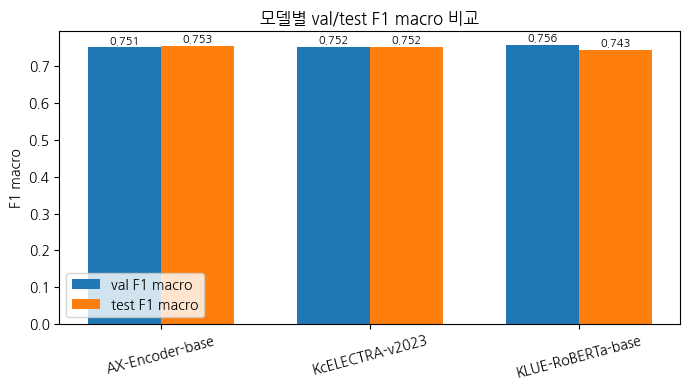

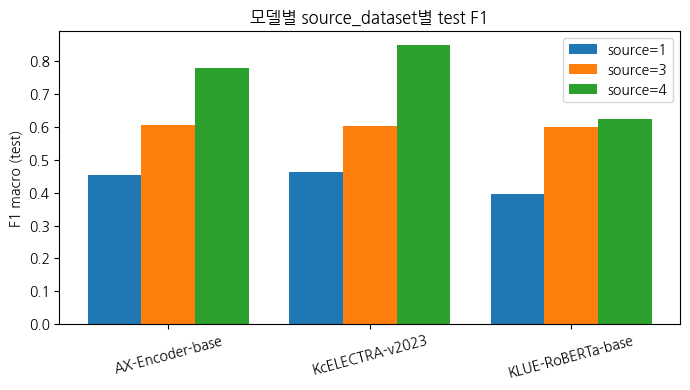

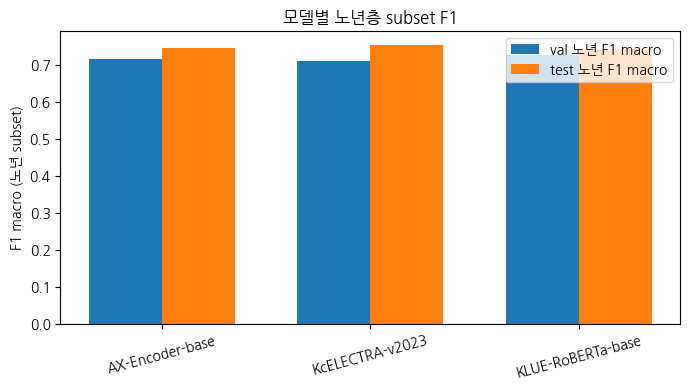

In [22]:
import matplotlib.pyplot as plt
import numpy as np

models = [r["model_key"] for r in summary]
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
val_f1 = [r["val"]["f1_macro_overall"] for r in summary]
test_f1 = [r["test"]["f1_macro_overall"] for r in summary]
ax.bar(x - width/2, val_f1, width, label="val F1 macro")
ax.bar(x + width/2, test_f1, width, label="test F1 macro")
for i, v in enumerate(val_f1):
    ax.text(i - width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
for i, v in enumerate(test_f1):
    ax.text(i + width/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("F1 macro"); ax.set_title("모델별 val/test F1 macro 비교")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "정의서_그림1_모델비교.png"), dpi=150)
plt.show()

sources = [1, 3, 4]
src_width = 0.8 / len(sources)
fig, ax = plt.subplots(figsize=(7, 4))
for j, src in enumerate(sources):
    vals = [r["test"].get(f"f1_macro_source_{src}", np.nan) for r in summary]
    offset = (j - (len(sources)-1)/2) * src_width
    ax.bar(x + offset, vals, src_width, label=f"source={src}")
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("F1 macro (test)"); ax.set_title("모델별 source_dataset별 test F1")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "정의서_그림2_source별비교.png"), dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
val_e = [r["val"]["f1_macro_elderly"] for r in summary]
test_e = [r["test"]["f1_macro_elderly"] for r in summary]
ax.bar(x - width/2, val_e, width, label="val 노년 F1 macro")
ax.bar(x + width/2, test_e, width, label="test 노년 F1 macro")
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("F1 macro (노년 subset)"); ax.set_title("모델별 노년층 subset F1")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "정의서_그림3_노년층비교.png"), dpi=150)
plt.show()

[markdown] 셀 3 설명

정의서 그림 4: epoch별 train/eval loss와 eval F1 추이(과적합 여부 확인용). log_history가 저장된 모델만 그려집니다.

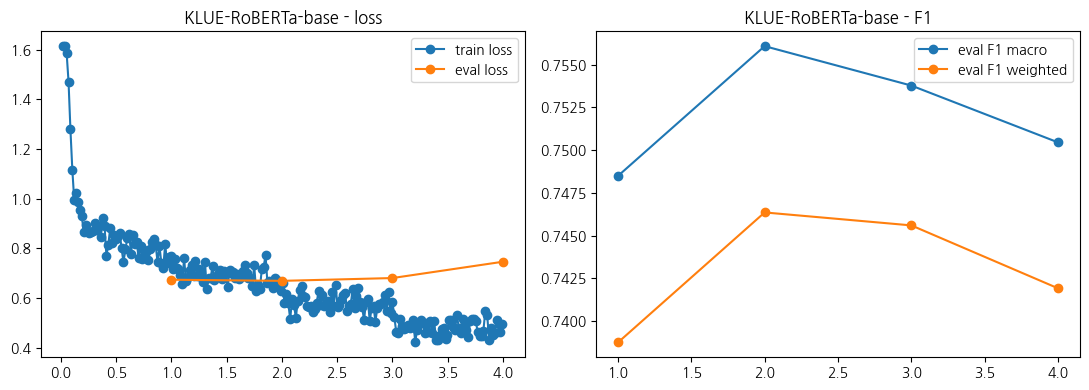

In [23]:
with_history = [r for r in summary if r.get("log_history")]
if not with_history:
    print("[안내] log_history 있는 모델 없음")
else:
    fig, axes = plt.subplots(len(with_history), 2, figsize=(11, 4*len(with_history)), squeeze=False)
    for i, r in enumerate(with_history):
        hist = r["log_history"]
        train_pts = sorted((h["epoch"], h["loss"]) for h in hist if "loss" in h and "epoch" in h)
        eval_pts = sorted((h["epoch"], h["eval_loss"], h.get("eval_f1_macro"), h.get("eval_f1_weighted")) for h in hist if "eval_loss" in h)
        ax_loss, ax_f1 = axes[i]
        if train_pts: ax_loss.plot(*zip(*train_pts), marker="o", label="train loss")
        if eval_pts:
            ep = [p[0] for p in eval_pts]
            ax_loss.plot(ep, [p[1] for p in eval_pts], marker="o", label="eval loss")
            ax_f1.plot(ep, [p[2] for p in eval_pts], marker="o", label="eval F1 macro")
            ax_f1.plot(ep, [p[3] for p in eval_pts], marker="o", label="eval F1 weighted")
        ax_loss.set_title(f"{r['model_key']} - loss"); ax_loss.legend()
        ax_f1.set_title(f"{r['model_key']} - F1"); ax_f1.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_ROOT, "정의서_그림4_학습곡선.png"), dpi=150)
    plt.show()

val_df/test_df도 재시작하면서 날아간 겁니다(체크포인트랑 별개로, 이건 그냥 CSV 읽는 거라 Drive에서 다시 로드하면 됩니다 — 학습 아님, 몇 초 걸림). 아래 셀 먼저 실행하고 재추론 셀 다시 돌리세요.

In [27]:
def load_split(name: str) -> pd.DataFrame:
    path = os.path.join(DATA_DIR, f"{name}.csv")
    df = pd.read_csv(path, encoding="utf-8-sig")
    missing = set(["context", "text", "label", "source_dataset", "age_group"]) - set(df.columns)
    if missing:
        raise ValueError(f"{path}에 필요한 컬럼이 없습니다: {missing}")
    df["label_id"] = df["label"].map(LABEL2ID)
    if df["label_id"].isna().any():
        bad = df[df["label_id"].isna()]["label"].unique()
        raise ValueError(f"알 수 없는 라벨 값 발견: {bad}")
    return df

train_df = load_split("train")
val_df = load_split("val")
test_df = load_split("test")
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

train=46648  val=5816  test=5877


[markdown] 셀 4 설명

혼동행렬·클래스별 지표를 그리려면 원시 예측값(preds/labels)이 필요한데, 지금까지 코드는 요약 지표만 계산하고 버렸습니다. 그래서 저장된 best_model 체크포인트를 다시 불러와 추론만 다시 돌립니다 — trainer.train()은 호출하지 않으므로 재학습이 아니라 GPU 몇 분이면 끝납니다. 체크포인트가 없는 모델은 자동으로 건너뜁니다.

In [28]:
def reload_and_predict(result_entry, df):
    model_path = result_entry["best_model_path"]
    if not os.path.isdir(model_path):
        print(f"[건너뜀] {result_entry['model_key']} — 체크포인트 없음")
        return None
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(model_path, torch_dtype=torch.float32)
    use_tti = getattr(model.config, "type_vocab_size", 2) > 1
    ds = EmotionDataset(df, tokenizer, MAX_LENGTH, use_token_type_ids=use_tti)
    args = TrainingArguments(output_dir="/tmp/_infer_only", per_device_eval_batch_size=EVAL_BATCH_SIZE, report_to=[], fp16=torch.cuda.is_available())
    trainer = Trainer(model=model, args=args, data_collator=DataCollatorWithPadding(tokenizer=tokenizer))
    pred_output = trainer.predict(ds)
    preds = np.argmax(pred_output.predictions, axis=-1)
    labels = pred_output.label_ids
    report = classification_report(labels, preds, target_names=LABELS, digits=3, output_dict=True)
    return preds, labels, report

raw_predictions = {}
for r in summary:
    raw_predictions[r["model_key"]] = {}
    for split_name, df in [("val", val_df), ("test", test_df)]:
        out = reload_and_predict(r, df)
        if out is not None:
            raw_predictions[r["model_key"]][split_name] = out
            print(f"[완료] {r['model_key']}/{split_name}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

[완료] AX-Encoder-base/val


Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

[완료] AX-Encoder-base/test


...

[완료] KcELECTRA-v2023/test


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[완료] KLUE-RoBERTa-base/val


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[완료] KLUE-RoBERTa-base/test


[markdown] 셀 5 설명

정의서 그림 5: 혼동행렬 히트맵(모델×val/test). 중립↔불안 confound, 슬픔 재현율 저조가 실제로 어디서 새는지 보여줍니다. 셀 4 결과가 필요합니다.

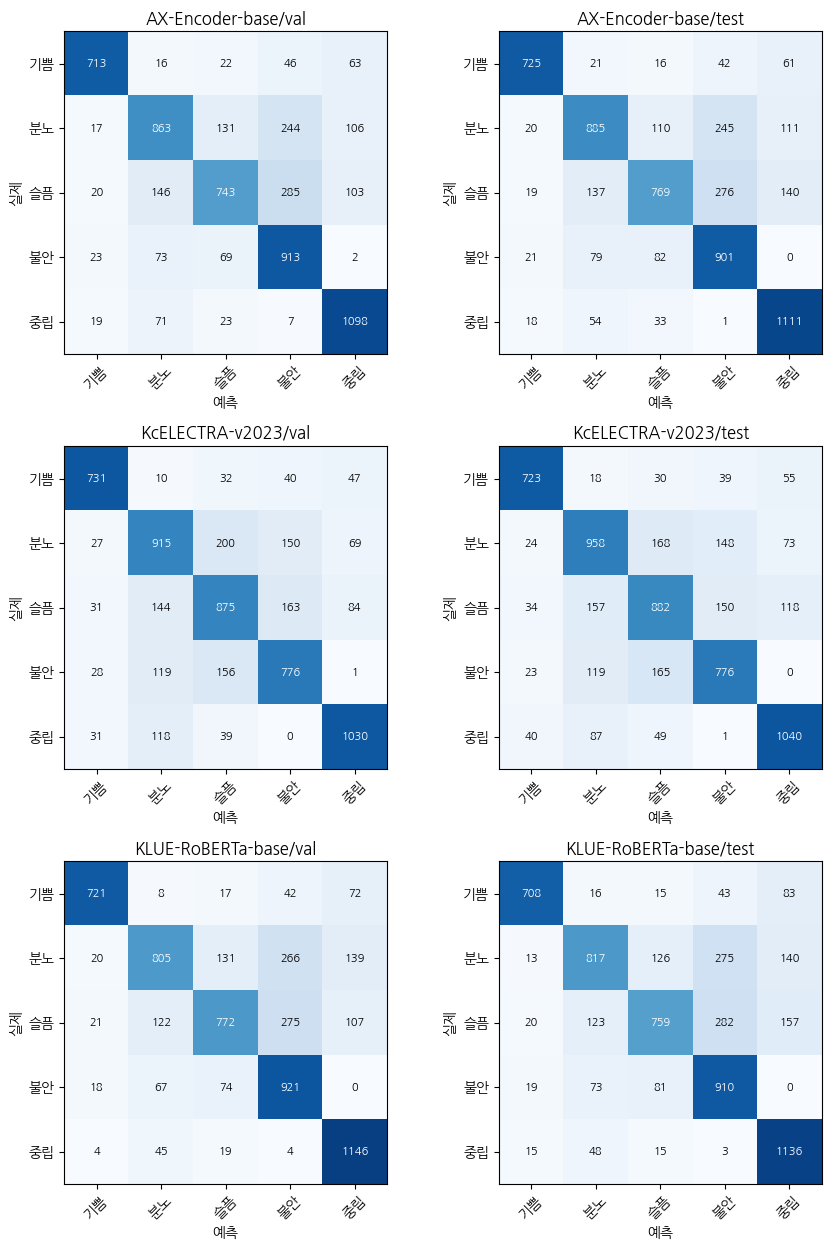

In [29]:
from sklearn.metrics import confusion_matrix

n_models = len(raw_predictions)
fig, axes = plt.subplots(n_models, 2, figsize=(9, 4.2*n_models), squeeze=False)
for i, (model_key, splits) in enumerate(raw_predictions.items()):
    for j, split_name in enumerate(["val", "test"]):
        ax = axes[i][j]
        if split_name not in splits:
            ax.axis("off"); ax.set_title(f"{model_key}/{split_name} 없음"); continue
        preds, labels, _ = splits[split_name]
        cm = confusion_matrix(labels, preds, labels=range(len(LABELS)))
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45)
        ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
        ax.set_xlabel("예측"); ax.set_ylabel("실제"); ax.set_title(f"{model_key}/{split_name}")
        for ri in range(len(LABELS)):
            for ci in range(len(LABELS)):
                ax.text(ci, ri, cm[ri, ci], ha="center", va="center", color="white" if cm_norm[ri, ci] > 0.5 else "black", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "정의서_그림5_혼동행렬.png"), dpi=150)
plt.show()

[markdown] 셀 6 설명

정의서 그림 6 + 표: 클래스별 precision/recall/F1 막대그래프와 CSV. 클래스 불균형이 실제 성능에 남긴 흔적을 보여줍니다. 셀 4 결과가 필요합니다.

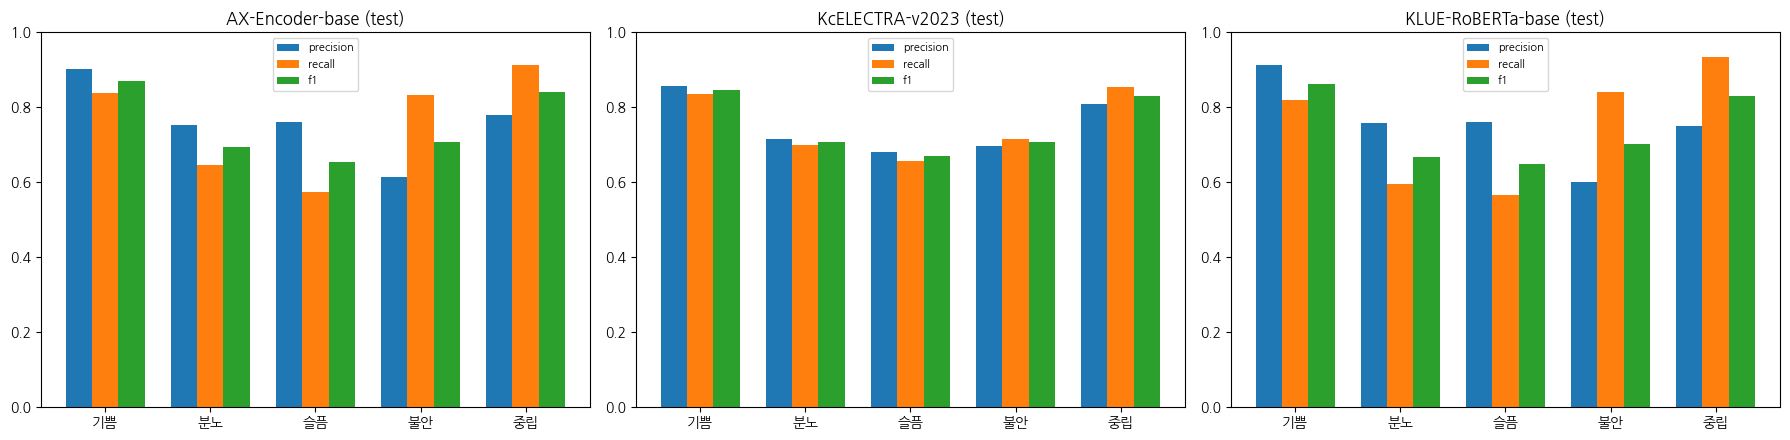

In [30]:
fig, axes = plt.subplots(1, len(raw_predictions), figsize=(6*len(raw_predictions), 4.5), squeeze=False)
axes = axes[0]
for ax, (model_key, splits) in zip(axes, raw_predictions.items()):
    if "test" not in splits:
        ax.axis("off"); continue
    _, _, report = splits["test"]
    x = np.arange(len(LABELS)); w = 0.25
    ax.bar(x - w, [report[l]["precision"] for l in LABELS], w, label="precision")
    ax.bar(x, [report[l]["recall"] for l in LABELS], w, label="recall")
    ax.bar(x + w, [report[l]["f1-score"] for l in LABELS], w, label="f1")
    ax.set_xticks(x); ax.set_xticklabels(LABELS); ax.set_ylim(0, 1)
    ax.set_title(f"{model_key} (test)"); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "정의서_그림6_클래스별지표.png"), dpi=150)
plt.show()

rows = []
for model_key, splits in raw_predictions.items():
    for split_name, (_, _, report) in splits.items():
        for label in LABELS:
            rows.append({"model": model_key, "split": split_name, "class": label,
                         "precision": report[label]["precision"], "recall": report[label]["recall"],
                         "f1": report[label]["f1-score"], "support": report[label]["support"]})
pd.DataFrame(rows).to_csv(os.path.join(OUTPUT_ROOT, "정의서_표_클래스별지표.csv"), index=False)